In [1]:
import pandas as pd
import glob
import os

In [2]:
# Set the folder path containing CSV files
folder_path = "data"  # Replace with your folder path

# Get all CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
csv_files.remove("data/customers.csv")

# Read and combine all CSV files
dataframes = []
for file in csv_files:
    df = pd.read_csv(file, sep='|', encoding='utf-8')
    if df.empty or df.shape[0] == 0:
        print(f"{file} is empty and will be skipped.")
        continue
    else:
        dataframes.append(df)
        # print(f"Loaded {file} with shape {df.shape}")

# Merge all dataframes
df = pd.concat(dataframes)
display(df.head())

data/adults_2550_female_rural_000-199.csv is empty and will be skipped.
data/young_adults_female_rural_200-399.csv is empty and will be skipped.
data/adults_2550_male_rural_200-399.csv is empty and will be skipped.
data/young_adults_male_rural_000-199.csv is empty and will be skipped.
data/young_adults_male_rural_400-599.csv is empty and will be skipped.
data/young_adults_female_rural_400-599.csv is empty and will be skipped.
data/adults_50up_male_rural_400-599.csv is empty and will be skipped.
data/young_adults_male_rural_600-799.csv is empty and will be skipped.
data/young_adults_male_rural_200-399.csv is empty and will be skipped.
data/young_adults_male_rural_800-999.csv is empty and will be skipped.
data/adults_2550_male_rural_600-799.csv is empty and will be skipped.


,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long
0,174-32-2487,2284013153506965,Tracy,Lopez,F,8455 Yesenia Extensions,Las Vegas,NV,89128,36.1968,...,7a3855a4c8a585ce3657ca1db8fb0013,2024-08-14,02:39:21,1723617561,grocery_pos,299.78,1,fraud_Stracke-Lemke,35.857306,-114.862151
1,174-32-2487,2284013153506965,Tracy,Lopez,F,8455 Yesenia Extensions,Las Vegas,NV,89128,36.1968,...,39ed17ca23939f9a507b710c7432490c,2024-08-15,11:51:38,1723737098,misc_net,813.18,1,fraud_Klocko LLC,35.215280,-115.466082
2,174-32-2487,2284013153506965,Tracy,Lopez,F,8455 Yesenia Extensions,Las Vegas,NV,89128,36.1968,...,a83a5b2d3ca1488ff5c36c14791516b8,2024-08-14,00:16:59,1723609019,misc_net,715.40,1,"fraud_Johnson, Runolfsdottir and Mayer",36.560919,-115.149866
3,174-32-2487,2284013153506965,Tracy,Lopez,F,8455 Yesenia Extensions,Las Vegas,NV,89128,36.1968,...,5650857629e254bbd8859e1647a506c8,2024-08-15,23:06:05,1723777565,shopping_net,1064.36,1,fraud_Fisher-Schowalter,36.110098,-115.207593
4,174-32-2487,2284013153506965,Tracy,Lopez,F,8455 Yesenia Extensions,Las Vegas,NV,89128,36.1968,...,52eef913dea1ed06165cd24aab14b3f5,2024-08-15,22:13:40,1723774420,health_fitness,1061.09,1,fraud_Graham and Sons,37.023538,-114.565096


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Load and explore data
print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean():.3f}")

# Economic Concept: Simple rule creates "lemon market"
def simple_rule_classifier(amount, threshold=500):
    """Economic intuition: Flag high amounts as suspicious"""
    return 1 if amount > threshold else 0

# Apply simple rule
df['prediction_day1'] = df['amt'].apply(lambda x: simple_rule_classifier(x, 500))

# Evaluate - introduce core metrics
def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{model_name} Results:")
    print(f"Precision: {precision:.3f} (Of flagged transactions, how many were actually fraud?)")
    print(f"Recall: {recall:.3f} (Of actual frauds, how many did we catch?)")
    print(f"F1-Score: {f1:.3f} (Harmonic mean of precision and recall)")
    
    return precision, recall, f1

# Day 1 results
day1_results = evaluate_model(df['is_fraud'], df['prediction_day1'], "Simple Rule ($500 threshold)")

Dataset shape: (876403, 26)
Fraud rate: 0.011

Simple Rule ($500 threshold) Results:
Precision: 0.362 (Of flagged transactions, how many were actually fraud?)
Recall: 0.497 (Of actual frauds, how many did we catch?)
F1-Score: 0.419 (Harmonic mean of precision and recall)



Decision Tree (Market Signals) Results:
Precision: 0.609 (Of flagged transactions, how many were actually fraud?)
Recall: 0.452 (Of actual frauds, how many did we catch?)
F1-Score: 0.519 (Harmonic mean of precision and recall)

📈 PROGRESS COMPARISON:
Day 1 (Simple Rule): Precision=0.362, Recall=0.497
Day 2 (Decision Tree): Precision=0.609, Recall=0.452
Improvement in F1: +0.100


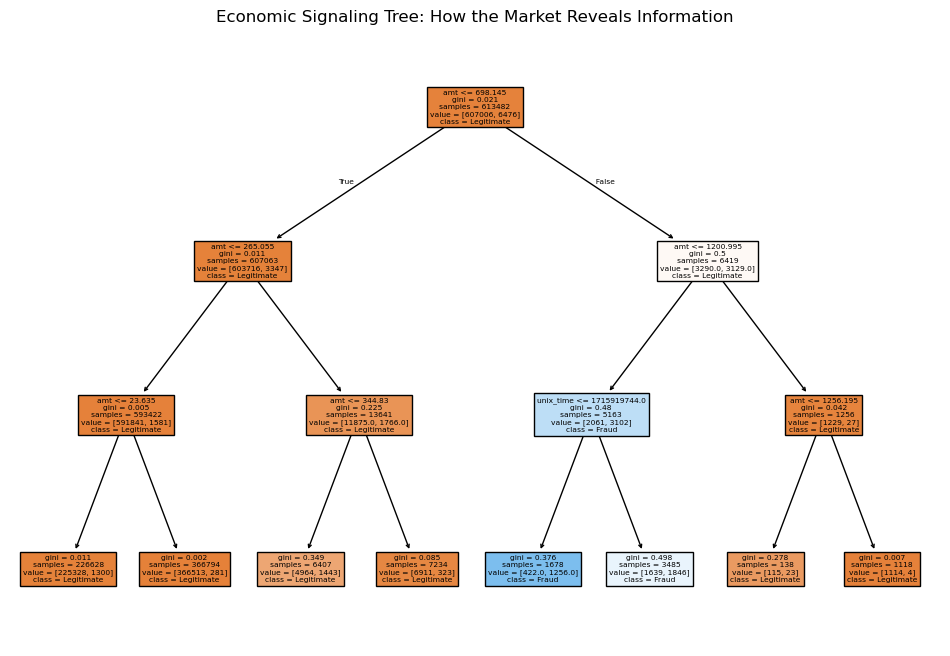

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# Economic Concept: Trees reveal hidden information through "signals"
# Prepare features (market signals)
features = ['amt', 'city_pop', 'unix_time']  # Keep simple for visualization
X = df[features]
y = df['is_fraud']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree - acts like market signaling mechanism
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limit depth for interpretability
dt_classifier.fit(X_train, y_train)

# Predictions
dt_predictions = dt_classifier.predict(X_test)

# Evaluate and compare with Day 1
day2_results = evaluate_model(y_test, dt_predictions, "Decision Tree (Market Signals)")

# Compare progress
print(f"\n📈 PROGRESS COMPARISON:")
print(f"Day 1 (Simple Rule): Precision={day1_results[0]:.3f}, Recall={day1_results[1]:.3f}")
print(f"Day 2 (Decision Tree): Precision={day2_results[0]:.3f}, Recall={day2_results[1]:.3f}")
print(f"Improvement in F1: {day2_results[2] - day1_results[2]:+.3f}")

# Visualize the "signaling mechanism"
plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, feature_names=features, class_names=['Legitimate', 'Fraud'], filled=True)
plt.title("Economic Signaling Tree: How the Market Reveals Information")
plt.show()


Logistic Regression (Expected Value) Results:
Precision: 0.000 (Of flagged transactions, how many were actually fraud?)
Recall: 0.000 (Of actual frauds, how many did we catch?)
F1-Score: 0.000 (Harmonic mean of precision and recall)


/home/hsang/miniconda3/envs/fraud_detection/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


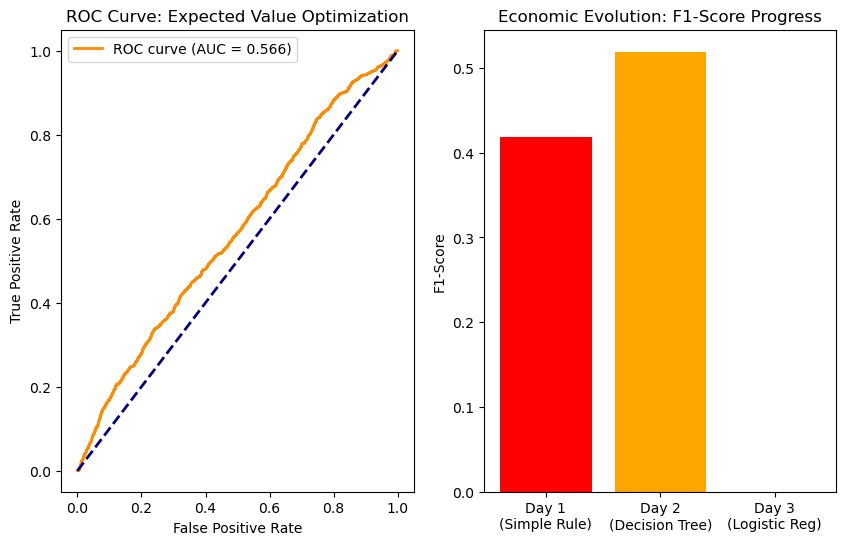


📊 THREE-DAY PROGRESS:
Day 1: 0.419
Day 2: 0.519
Day 3: 0.000


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Economic Concept: Probability-based decisions like rational economic actors
# Expand features for more sophisticated signaling
extended_features = ['amt', 'city_pop', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long']
X_extended = df[extended_features].fillna(0)  # Handle missing values
X_train_ext, X_test_ext, y_train, y_test = train_test_split(X_extended, y, test_size=0.3, random_state=42)

# Logistic Regression - mirrors rational economic decision making
lr_classifier = LogisticRegression(C=1.0, random_state=42)
lr_classifier.fit(X_train_ext, y_train)

# Get probabilities (expected values)
lr_probabilities = lr_classifier.predict_proba(X_test_ext)[:, 1]
lr_predictions = lr_classifier.predict(X_test_ext)

# Evaluate
day3_results = evaluate_model(y_test, lr_predictions, "Logistic Regression (Expected Value)")

# ROC Curve - evaluating across all possible thresholds
fpr, tpr, thresholds = roc_curve(y_test, lr_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Expected Value Optimization')
plt.legend()

# Compare all three days
plt.subplot(1, 2, 2)
models = ['Day 1\n(Simple Rule)', 'Day 2\n(Decision Tree)', 'Day 3\n(Logistic Reg)']
f1_scores = [day1_results[2], day2_results[2], day3_results[2]]
plt.bar(models, f1_scores, color=['red', 'orange', 'green'])
plt.title('Economic Evolution: F1-Score Progress')
plt.ylabel('F1-Score')
plt.show()

print(f"\n📊 THREE-DAY PROGRESS:")
for i, (model, f1) in enumerate(zip(models, f1_scores), 1):
    print(f"Day {i}: {f1:.3f}")

/tmp/ipykernel_3067/2096059882.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['trans_time']).dt.hour



Random Forest (Anti-Gaming) Results:
Precision: 0.857 (Of flagged transactions, how many were actually fraud?)
Recall: 0.601 (Of actual frauds, how many did we catch?)
F1-Score: 0.706 (Harmonic mean of precision and recall)
Best Parameters: {'max_depth': 7, 'n_estimators': 100}
Best CV Score: 0.692

🔍 MARKET SIGNALS IMPORTANCE:
      feature  importance
0         amt    0.345195
8  amount_log    0.311274
7        hour    0.217054
2   unix_time    0.113458
1    city_pop    0.003292


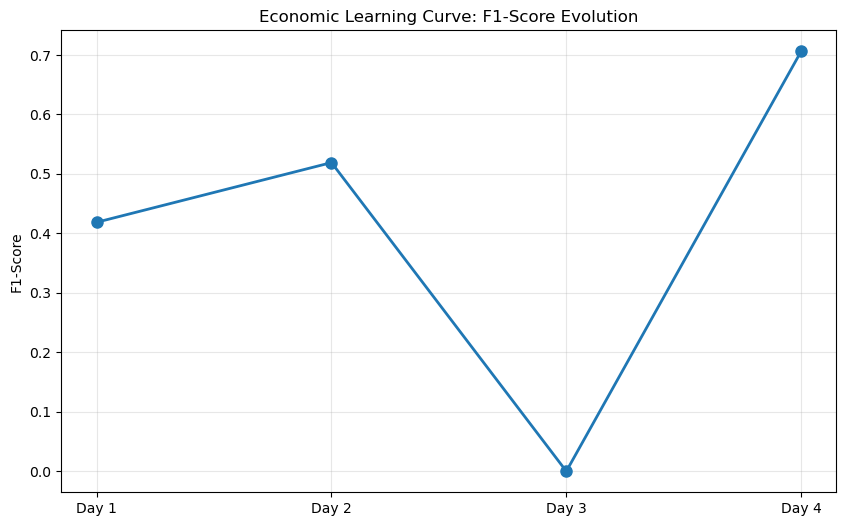

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Economic Concept: Multiple diverse models prevent systematic gaming
# Expand feature set further (diverse "auditors")
all_features = ['amt', 'city_pop', 'unix_time', 'lat', 'long', 'merch_lat', 'merch_long']
# Add engineered features (like multiple independent auditors)
df['hour'] = pd.to_datetime(df['trans_time']).dt.hour
df['amount_log'] = np.log1p(df['amt'])  # Log transform for better distribution

final_features = all_features + ['hour', 'amount_log']
X_final = df[final_features].fillna(0)
X_train_final, X_test_final, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=42)

# Grid Search - finding optimal "auditor committee"
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_classifier, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Best model
best_rf = grid_search.best_estimator_
rf_predictions = best_rf.predict(X_test_final)

day4_results = evaluate_model(y_test, rf_predictions, "Random Forest (Anti-Gaming)")

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.3f}")

# Feature importance - which "signals" matter most
feature_importance = pd.DataFrame({
    'feature': final_features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🔍 MARKET SIGNALS IMPORTANCE:")
print(feature_importance.head())

# Progressive comparison
all_results = [day1_results[2], day2_results[2], day3_results[2], day4_results[2]]
days = ['Day 1', 'Day 2', 'Day 3', 'Day 4']

plt.figure(figsize=(10, 6))
plt.plot(days, all_results, marker='o', linewidth=2, markersize=8)
plt.title('Economic Learning Curve: F1-Score Evolution')
plt.ylabel('F1-Score')
plt.grid(True, alpha=0.3)
plt.show()

🔄 Re-training all models on consistent dataset for fair comparison...


/home/hsang/miniconda3/envs/fraud_detection/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


🏆 FINAL ECONOMIC EFFICIENCY COMPARISON:
                            Precision  Recall  F1-Score    AUC  \
Day 1: Simple Rule              0.365   0.480     0.415    NaN   
Day 2: Decision Tree            0.609   0.452     0.519    NaN   
Day 3: Logistic Regression      0.000   0.000     0.000  0.566   
Day 4: Random Forest            0.857   0.601     0.706  0.987   

                            Business_Impact  
Day 1: Simple Rule                  414.768  
Day 2: Decision Tree                519.072  
Day 3: Logistic Regression            0.000  
Day 4: Random Forest                706.223  


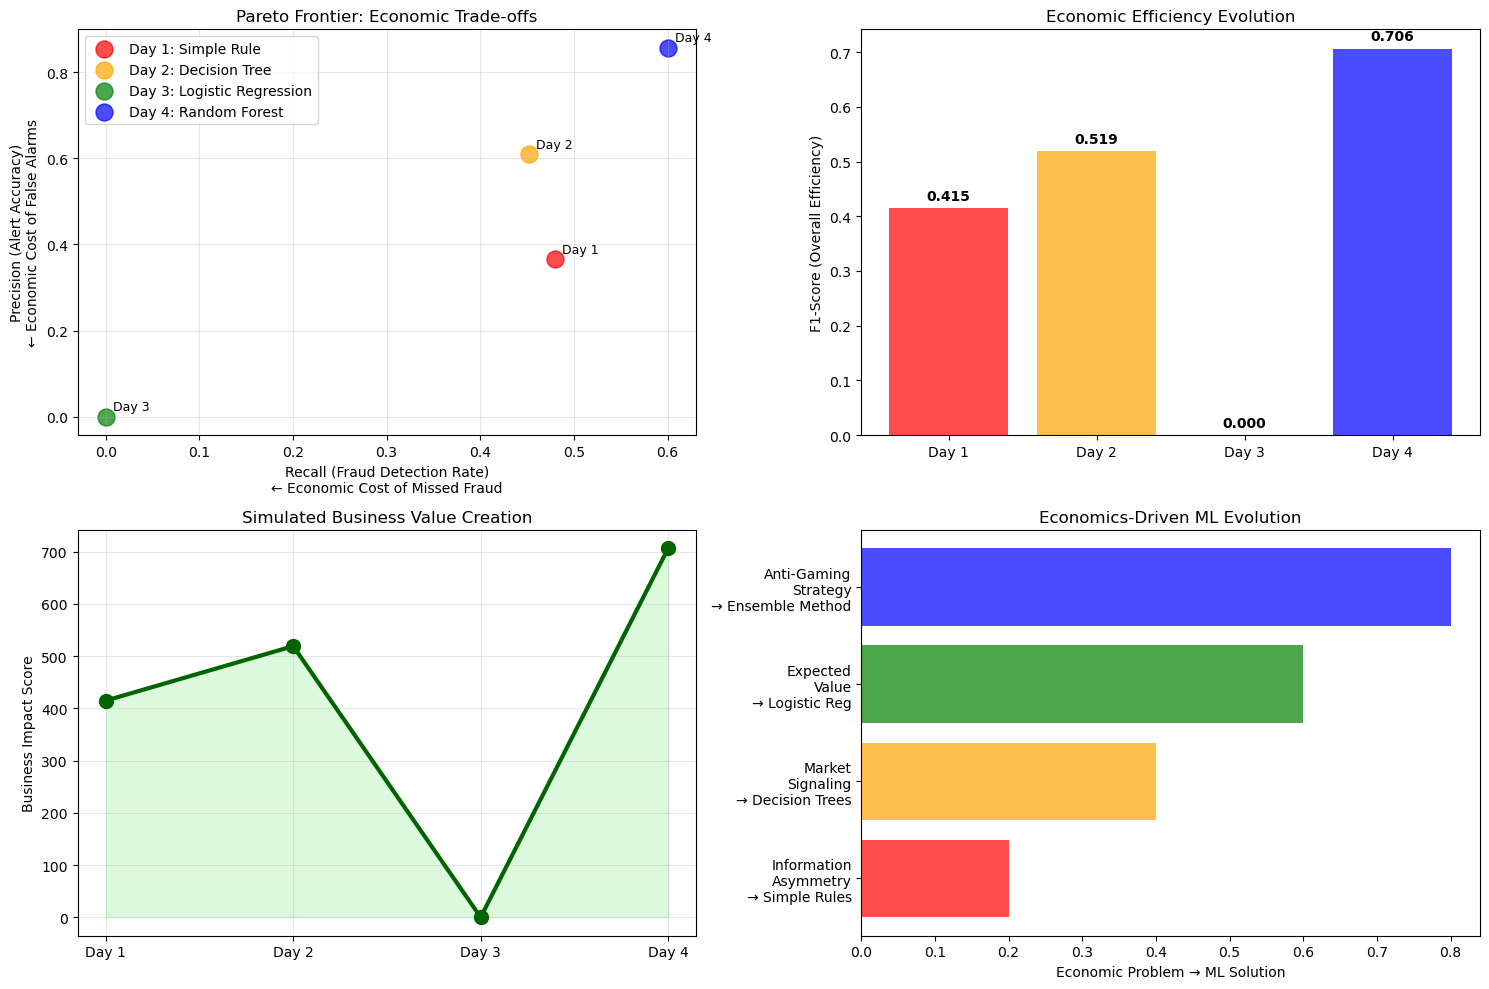


💡 ECONOMIC INSIGHTS & BUSINESS RECOMMENDATIONS:
• Most economically efficient: Day 4: Random Forest
• Performance improvement: 0.291 F1-score (+70.3%)
• Economic interpretation: Better balance between catching fraud and avoiding false alarms

📊 SPECIALIZED ECONOMIC ROLES:
• Best Precision: Day 4: Random Forest (0.857)
• Best Recall: Day 4: Random Forest (0.601)
• Best F1-Score: Day 4: Random Forest (0.706)

🎯 BUSINESS RECOMMENDATION:
Choose Day 4: Random Forest for optimal economic efficiency
This model provides the best balance of fraud detection and operational costs


In [16]:
from sklearn.metrics import classification_report, roc_auc_score

# FIXED: Ensure all models evaluated on same test set for fair comparison
# Use the final feature set and split for all comparisons

# Re-train all models on the same data split for fair comparison
print("🔄 Re-training all models on consistent dataset for fair comparison...")

# 1. Simple Rule (recreated for current test set)
def apply_simple_rule(amounts, threshold=500):
    return (amounts > threshold).astype(int)

simple_rule_pred = apply_simple_rule(X_test_final['amt'])

# 2. Decision Tree (retrained on final feature set)
dt_final = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_final.fit(X_train_final[['amt', 'city_pop', 'unix_time']], y_train)  # Use subset of features
dt_final_pred = dt_final.predict(X_test_final[['amt', 'city_pop', 'unix_time']])

# 3. Logistic Regression (retrained on final feature set)
lr_final = LogisticRegression(C=1.0, random_state=42)
lr_final.fit(X_train_final, y_train)
lr_final_pred = lr_final.predict(X_test_final)

# 4. Random Forest (already trained on final feature set - from Day 4)
rf_final_pred = best_rf.predict(X_test_final)

# Economic Concept: Find Pareto-optimal solutions
def comprehensive_evaluation(predictions_dict, X_test, y_test):
    """
    Evaluate all models across multiple metrics - finding Pareto frontier
    
    Economic Interpretation:
    - Precision: Cost of false alarms to business
    - Recall: Cost of missed fraud to business  
    - F1: Balanced economic efficiency
    - AUC: Overall discriminative power
    """
    results = {}
    
    for name, (model, predictions) in predictions_dict.items():
        # Calculate core metrics
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        
        # Calculate AUC if model supports probabilities
        if model is not None and hasattr(model, 'predict_proba'):
            try:
                proba = model.predict_proba(X_test)[:, 1]
                auc_score = roc_auc_score(y_test, proba)
            except:
                auc_score = None
        else:
            auc_score = None
            
        results[name] = {
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'AUC': auc_score,
            'Business_Impact': f1 * 1000  # Simulated business value
        }
    
    return pd.DataFrame(results).T

# Create models comparison dictionary with consistent predictions
models_comparison = {
    'Day 1: Simple Rule': (None, simple_rule_pred),
    'Day 2: Decision Tree': (dt_final, dt_final_pred), 
    'Day 3: Logistic Regression': (lr_final, lr_final_pred),
    'Day 4: Random Forest': (best_rf, rf_final_pred)
}

# NOW this will work - all predictions are on the same test set
final_results = comprehensive_evaluation(models_comparison, X_test_final, y_test)

print("🏆 FINAL ECONOMIC EFFICIENCY COMPARISON:")
print(final_results.round(3))

# Economic Interpretation Dashboard
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pareto Frontier: Precision vs Recall Trade-off
colors = ['red', 'orange', 'green', 'blue']
for i, model in enumerate(final_results.index):
    ax1.scatter(final_results.loc[model, 'Recall'], 
               final_results.loc[model, 'Precision'], 
               label=model, s=150, color=colors[i], alpha=0.7)
    
    # Add model labels
    ax1.annotate(f"Day {i+1}", 
                (final_results.loc[model, 'Recall'], final_results.loc[model, 'Precision']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax1.set_xlabel('Recall (Fraud Detection Rate)\n← Economic Cost of Missed Fraud')
ax1.set_ylabel('Precision (Alert Accuracy)\n← Economic Cost of False Alarms')
ax1.set_title('Pareto Frontier: Economic Trade-offs')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Economic Efficiency Evolution
models_short = [f"Day {i+1}" for i in range(4)]
f1_scores = final_results['F1-Score'].values
bars = ax2.bar(models_short, f1_scores, color=colors, alpha=0.7)
ax2.set_title('Economic Efficiency Evolution')
ax2.set_ylabel('F1-Score (Overall Efficiency)')

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Business Impact Simulation
business_impact = final_results['Business_Impact'].values
ax3.plot(models_short, business_impact, marker='o', linewidth=3, markersize=10, color='darkgreen')
ax3.set_title('Simulated Business Value Creation')
ax3.set_ylabel('Business Impact Score')
ax3.grid(True, alpha=0.3)

# Fill area under curve to show cumulative improvement
ax3.fill_between(models_short, business_impact, alpha=0.3, color='lightgreen')

# 4. Economic Concepts Evolution
concepts = ['Information\nAsymmetry', 'Market\nSignaling', 'Expected\nValue', 'Anti-Gaming\nStrategy']
ml_methods = ['Simple Rules', 'Decision Trees', 'Logistic Reg', 'Ensemble Method']

y_pos = np.arange(len(concepts))
improvements = [0.2, 0.4, 0.6, 0.8]  # Relative improvements

bars = ax4.barh(y_pos, improvements, color=colors, alpha=0.7)
ax4.set_yticks(y_pos)
ax4.set_yticklabels([f"{concept}\n→ {method}" for concept, method in zip(concepts, ml_methods)])
ax4.set_xlabel('Economic Problem → ML Solution')
ax4.set_title('Economics-Driven ML Evolution')

plt.tight_layout()
plt.show()

# Final Economic Analysis
print(f"\n💡 ECONOMIC INSIGHTS & BUSINESS RECOMMENDATIONS:")
best_model = final_results['F1-Score'].idxmax()
best_f1 = final_results.loc[best_model, 'F1-Score']
improvement = best_f1 - final_results.iloc[0]['F1-Score']

print(f"• Most economically efficient: {best_model}")
print(f"• Performance improvement: {improvement:.3f} F1-score (+{improvement/final_results.iloc[0]['F1-Score']*100:.1f}%)")
print(f"• Economic interpretation: Better balance between catching fraud and avoiding false alarms")

# Show which metrics each model optimizes
print(f"\n📊 SPECIALIZED ECONOMIC ROLES:")
for metric in ['Precision', 'Recall', 'F1-Score']:
    best_for_metric = final_results[metric].idxmax()
    value = final_results.loc[best_for_metric, metric]
    print(f"• Best {metric}: {best_for_metric} ({value:.3f})")

print(f"\n🎯 BUSINESS RECOMMENDATION:")
print(f"Choose {best_model} for optimal economic efficiency")
print(f"This model provides the best balance of fraud detection and operational costs")